# What happens to donations when a charity gains DGR status?

An event study of 646 established charities that gained DGR endorsement between FY2019 and FY2024 (ACNC Annual Information Statements joined to ABR endorsement dates, ancillary funds and start-ups excluded).

**Key messages:**
1. **The typical newly endorsed charity grew its donations by ~30% in real terms** (+47% nominal).
2. **The timing points to DGR as the cause**: each endorsement cohort's donations lift off in its own endorsement year, not in any common calendar year.
3. **The growth is concentrated in smaller charities** — charities raising under \\$10k/yr before endorsement, similar to the profile of the ~17,900 charities the reform would newly endorse (median ~\\$4.7k/yr).
4. **Lands inside the Productivity Commission's predicted range** for the price elasticity of giving — measured from the charity side. Note, the PC said this was insufficient to do given lack of data. This is largely correct: this event study has many other variables potentially contributing to the change in donations we are seeing.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = next(p for p in [Path("../dgr_event_study"), Path("analysis/dgr_event_study"), Path(".")]
            if (p / "switcher_panel.csv").exists())
panel = pd.read_csv(DATA / "switcher_panel.csv")

# established switchers only: charities that existed and reported BEFORE gaining DGR
est = panel[~panel["is_startup"]].copy()

# deflate to FY2019 dollars (ABS CPI 6401.0, financial-year average, 2019 = 100)
CPI = {2019: 100.0, 2020: 101.4, 2021: 103.1, 2022: 107.2, 2023: 114.7, 2024: 119.4}
est["donations_real"] = est["donations_and_bequests"] * 100 / est["ais_year"].map(CPI)


def within_charity_growth(df, value_col, pre_years=None):
    """Per-charity (post mean - pre mean) / pre mean.
    pre = event_year < 0 (or a custom set), post = event_year >= 1.
    Year 0 (endorsement year, partly treated) is in neither side."""
    pre_mask = df["event_year"] < 0 if pre_years is None else df["event_year"].isin(pre_years)
    g = pd.DataFrame({
        "pre": df[pre_mask].groupby("abn")[value_col].mean(),
        "post": df[df["event_year"] >= 1].groupby("abn")[value_col].mean(),
    }).dropna()
    g["growth"] = (g["post"] - g["pre"]) / g["pre"].clip(lower=1)
    return g


real = within_charity_growth(est, "donations_real")            # central estimate
nom = within_charity_growth(est, "donations_and_bequests")     # nominal, high
clean = within_charity_growth(est, "donations_real", pre_years=[-4, -3, -2])  # anticipation-robust

print(f"Established switcher charities with both pre and post years: {len(real):,}")
print(f"Median REAL growth (central estimate):        {real['growth'].median():+.1%}")
print(f"Median NOMINAL growth (high):                 {nom['growth'].median():+.1%}")
print(f"Anticipation-robust baseline (real, <= -2):   {clean['growth'].median():+.1%}")

Established switcher charities with both pre and post years: 646
Median REAL growth (central estimate):        +29.6%
Median NOMINAL growth (high):                 +47.0%
Anticipation-robust baseline (real, <= -2):   +29.3%


## 1. Every charity, sorted by its donation change

One bar per charity, sorted from the worst donation change to the best (real, CPI-adjusted dollars). The dashed line is the median. Half the charities did better than +30%, half did worse.

~1 in 3 charities donations fell. But median is best used here. 

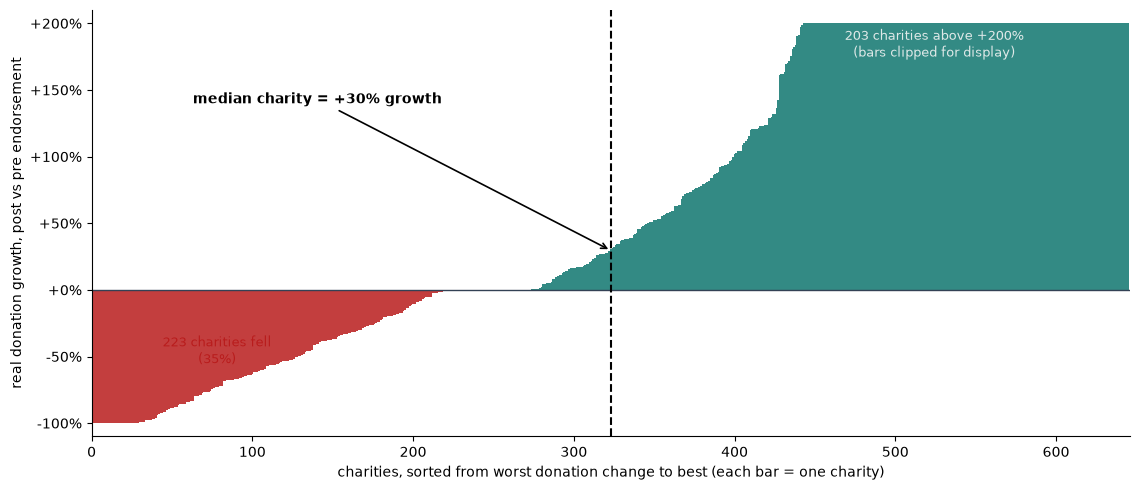

In [20]:
# The growth ladder: all charities as bars, sorted by real donation growth
names = est.groupby("abn")["charity_legal_name"].first()
g = real.join(names).sort_values("growth").reset_index(drop=True)
n = len(g)
med_rank = n // 2
med = g.loc[med_rank]
med_val = g["growth"].median()

CLIP = 2.0  # display clip at +200%
vals = g["growth"].clip(-1, CLIP)
colors = np.where(g["growth"] > 0, "#0f766e", "#b91c1c")

fig, ax = plt.subplots(figsize=(11.5, 5))
ax.bar(range(n), vals, width=1.0, color=colors, alpha=0.85)
ax.axhline(0, color="#334155", lw=1)

# mark the median bar with the actual middle charity
ax.axvline(med_rank, color="black", lw=1.5, ls="--")
ax.annotate(f"median charity = {med_val:+.0%} growth",
            xy=(med_rank, med_val), xytext=(med_rank - 260, 1.4),
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

n_neg = int((g["growth"] < 0).sum())
n_clip = int((g["growth"] > CLIP).sum())
ax.annotate(f"{n_neg} charities fell\n({n_neg / n:.0%})", xy=(n_neg * 0.35, -0.55),
            fontsize=9.5, color="#b91c1c", ha="center")
ax.annotate(f"{n_clip} charities above +200%\n(bars clipped for display)",
            xy=(n - n_clip * 0.6, 1.75), fontsize=9.5, color="#dfe9e8", ha="center")

ax.set_xlim(0, n)
ax.set_ylim(-1.1, 2.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_xlabel("charities, sorted from worst donation change to best (each bar = one charity)")
ax.set_ylabel("real donation growth, post vs pre endorsement")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 2. The timing suggests DGR is the impact

Each panel is one endorsement cohort, indexed to its own pre-endorsement median = 100. If the growth were COVID driven, inflation, or an economy-wide trend, all four panels would rise in the same calendar year. Instead, we see the lift-off follows each cohort's own endorsement year.

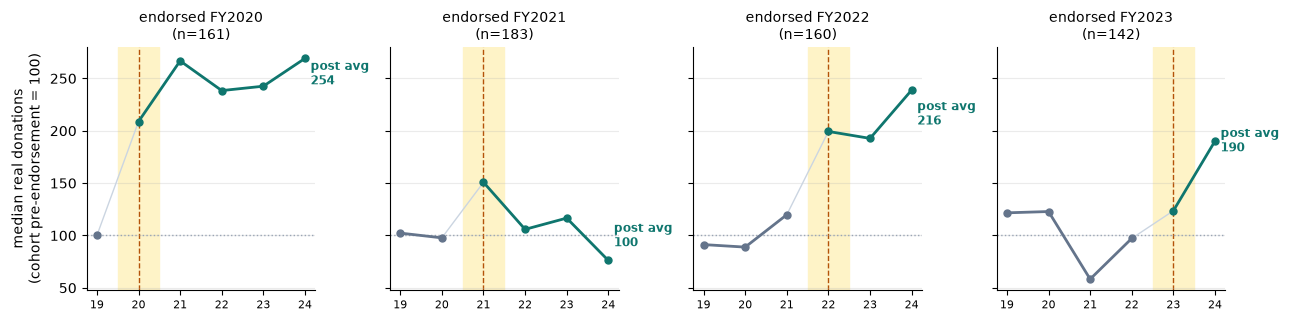

In [22]:
# Staggered cohorts, each indexed to its own pre-endorsement median = 100
cohorts = sorted(est["endorsement_fy"].unique())
fig, axes = plt.subplots(1, len(cohorts), figsize=(13, 3.9), sharey=True)

for ax, fy in zip(axes, cohorts):
    sub = est[est["endorsement_fy"] == fy]
    med = sub.groupby("ais_year")["donations_real"].median()
    base = med[med.index < fy].mean()
    med_idx = 100 * med / base
    n_ch = sub["abn"].nunique()

    pre_years = [y for y in med_idx.index if y < fy]
    post_years = [y for y in med_idx.index if y >= fy]
    ax.axhline(100, color="#94a3b8", lw=1, ls=":", zorder=1)
    ax.axvspan(fy - 0.5, fy + 0.5, color="#fef3c7", zorder=0)
    ax.axvline(fy, color="#b45309", lw=1, ls="--", zorder=1)
    ax.plot(med_idx.index, med_idx.values, color="#cbd5e1", lw=1, zorder=2)
    ax.plot(pre_years, med_idx.loc[pre_years], "o-", color="#64748b", lw=2, ms=5, zorder=3)
    ax.plot(post_years, med_idx.loc[post_years], "o-", color="#0f766e", lw=2, ms=5, zorder=3)

    post_avg = med_idx.loc[[y for y in post_years if y > fy]].mean()
    ax.annotate(f"post avg\n{post_avg:.0f}", xy=(max(med_idx.index), post_avg),
                xytext=(4, 0), textcoords="offset points",
                fontsize=8.5, color="#0f766e", fontweight="bold", va="center")

    ax.set_title(f"endorsed FY{fy}\n(n={n_ch})", fontsize=10)
    ax.set_xticks(med_idx.index)
    ax.set_xticklabels([str(y)[2:] for y in med_idx.index], fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("median real donations\n(cohort pre-endorsement = 100)")
#fig.suptitle("The rise starts at each cohort's own endorsement year — not in any common calendar year",
#             fontsize=12, fontweight="bold", x=0.01, ha="left")
#fig.text(0.01, 0.885, "Grey = before, teal = after, shaded band = endorsement FY. "
#         "Dotted line = the cohort's own pre-endorsement level.",
#         fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

## 3. The growth is concentrated in smaller charities

Splitting charities by their pre-endorsement donation level: the uplift is concentrated in smaller donation base charities (under $10k/yr), while established mid-size fundraisers see little real change.

**Why this matters:** the ~17,900 charities that would gain DGR under the reform have median donations of ~$4,700/yr --> within in the band with the strongest observed effect.

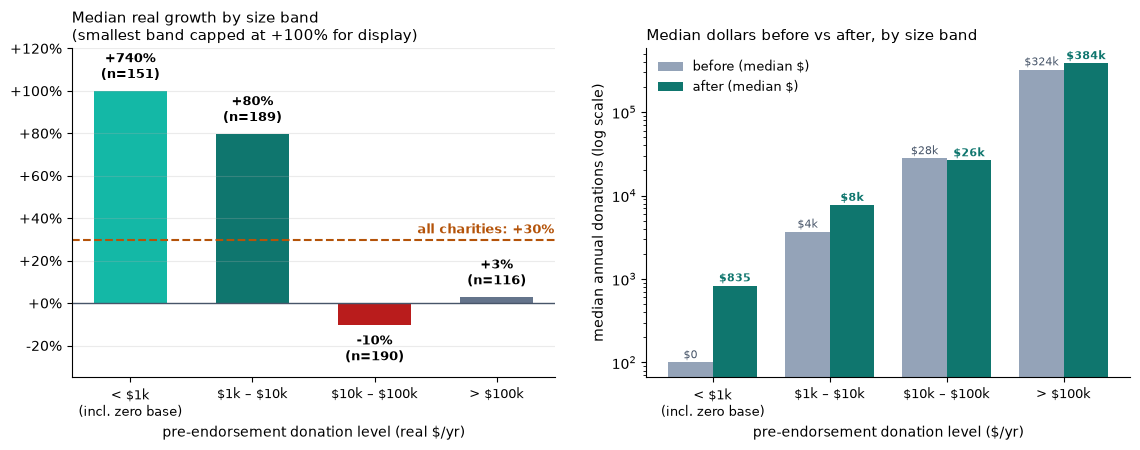

In [24]:
# Median real growth and median dollars, by pre-endorsement size band
d = real.copy()
bands = [0, 1_000, 10_000, 100_000, np.inf]
labels = ["< \\$1k\n(incl. zero base)", "\\$1k \u2013 \\$10k", "\\$10k \u2013 \\$100k", "> \\$100k"]
d["band"] = pd.cut(d["pre"], bands, labels=labels, right=False)

by_band = d.groupby("band", observed=True).agg(
    n=("growth", "size"),
    med_growth=("growth", "median"),
    share_up=("growth", lambda s: (s > 0).mean()),
    med_pre=("pre", "median"),
    med_post=("post", "median"),
)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))

colors = ["#14b8a6", "#0f766e", "#b91c1c", "#64748b"]
xp = np.arange(len(by_band))
capped = by_band["med_growth"].clip(-0.25, 1.0)
ax.bar(xp, capped, color=colors, width=0.6)
for i, (v, n_) in enumerate(zip(by_band["med_growth"], by_band["n"])):
    lbl = f"+{v:.0%}" if 0 <= v < 10 else (f"{v:.0%}" if v < 0 else f"+{v:,.0f}x")
    va = "bottom" if v >= 0 else "top"
    off = 6 if v >= 0 else -6
    ax.annotate(f"{lbl}\n(n={n_})", (i, float(np.clip(v, -0.25, 1.0))), xytext=(0, off),
                textcoords="offset points", ha="center", va=va, fontsize=9.5, fontweight="bold")
ax.axhline(0, color="#475569", lw=1)
ax.axhline(d["growth"].median(), color="#b45309", lw=1.5, ls="--")
ax.annotate(f"all charities: +{d['growth'].median():.0%}", xy=(2.35, d["growth"].median()),
            xytext=(0, 5), textcoords="offset points", color="#b45309", fontsize=9, fontweight="bold")
ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel("pre-endorsement donation level (real $/yr)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_ylim(-0.35, 1.2)
ax.set_title("Median real growth by size band\n(smallest band capped at +100% for display)",
             fontsize=10.5, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

width = 0.38
ax2.bar(xp - width / 2, by_band["med_pre"].clip(lower=100), width, color="#94a3b8", label="before (median $)")
ax2.bar(xp + width / 2, by_band["med_post"].clip(lower=100), width, color="#0f766e", label="after (median $)")
for i, (a_v, b_v) in enumerate(zip(by_band["med_pre"], by_band["med_post"])):
    ax2.annotate(f"\\${a_v / 1000:,.0f}k" if a_v >= 1000 else f"\\${a_v:,.0f}",
                 (i - width / 2, max(a_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#475569")
    ax2.annotate(f"\\${b_v / 1000:,.0f}k" if b_v >= 1000 else f"\\${b_v:,.0f}",
                 (i + width / 2, max(b_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#0f766e", fontweight="bold")
ax2.set_yscale("log")
ax2.set_xticks(xp); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_xlabel("pre-endorsement donation level ($/yr)")
ax2.set_ylabel("median annual donations (log scale)")
ax2.set_title("Median dollars before vs after, by size band", fontsize=10.5, loc="left")
ax2.legend(frameon=False, fontsize=9, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

#fig.suptitle("The growth is concentrated  in smaller charities",
#             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 3b. The same split through the ACNC's buckets: total revenue

Chart 3 bucketed charities by their pre-endorsement *donations* — but donations are the outcome being measured. Here we bucket by **total revenue**, using the ACNC's own charity-size definitions (which changed in FY2022):

| ACNC size | AIS 2022 onwards | AIS pre-2022 |
|---|---|---|
| Small | < \\$500k | < \\$250k |
| Medium | \\$500k – \\$3m | \\$250k – \\$1m |
| Large | > \\$3m | > \\$1m |

Each charity is classified in its **latest pre-endorsement year** (revenue and thresholds from that year), so the grouping cannot be contaminated by the post-endorsement outcome. The pattern matches chart 3: the uplift is strongest for small charities.

> **Reading the two panels together:** the left panel is the median of *within-charity* growth — for large charities it is 0% because 18% of them report zero donations both before and after (service-delivery organisations that never fundraise) and the rest split roughly evenly up/down. The right panel is the *cross-sectional* median dollar level of the group, computed independently before and after — a different statistic, pulled up by the charities that did grow. The within-charity median (left) is the honest headline; the dollar panel shows scale, not a contradiction.

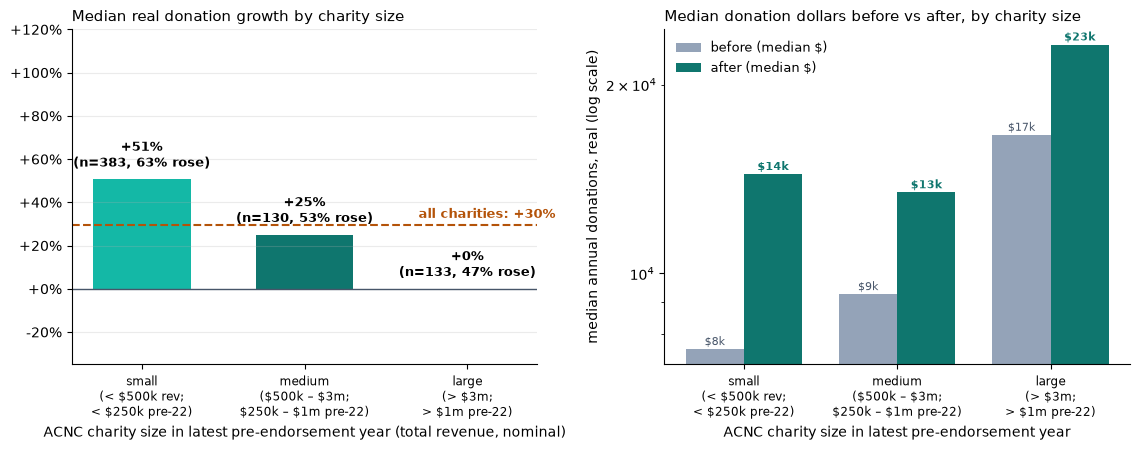

,n,med_growth,share_up,med_pre,med_post
size,,,,,
small,383,0.506012,0.626632,7572.678907,14394.321152
medium,130,0.249869,0.530769,9264.358114,13461.460042
large,133,0.000000,0.473684,16620.644313,23150.751903


In [25]:
# Same split, but by ACNC charity size (total revenue), thresholds as legislated:
# FY2022+: small < $500k, medium $500k-$3m, large > $3m
# pre-FY2022: small < $250k, medium $250k-$1m, large > $1m
SIZE_ORDER = ["small", "medium", "large"]


def acnc_size(rev, yr):
    lo, hi = (500_000, 3_000_000) if yr >= 2022 else (250_000, 1_000_000)
    return "small" if rev < lo else ("medium" if rev <= hi else "large")


# classify on the latest PRE-endorsement year (outcome-safe: uses no post data)
pre_rows = est[est["event_year"] < 0].dropna(subset=["total_gross_income"])
latest_pre = pre_rows.loc[pre_rows.groupby("abn")["ais_year"].idxmax()]
size_map = latest_pre.apply(lambda r: acnc_size(r["total_gross_income"], r["ais_year"]), axis=1)
size_map.index = latest_pre["abn"]

d = real.join(size_map.rename("size"), how="inner")
d["size"] = pd.Categorical(d["size"], categories=SIZE_ORDER, ordered=True)

by_size = d.groupby("size", observed=True).agg(
    n=("growth", "size"),
    med_growth=("growth", "median"),
    share_up=("growth", lambda s: (s > 0).mean()),
    med_pre=("pre", "median"),
    med_post=("post", "median"),
)

labels = ["small\n(< \\$500k rev;\n< \\$250k pre-22)",
          "medium\n(\\$500k \u2013 \\$3m;\n\\$250k \u2013 \\$1m pre-22)",
          "large\n(> \\$3m;\n> \\$1m pre-22)"]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))

colors = ["#14b8a6", "#0f766e", "#64748b"]
xp = np.arange(len(by_size))
capped = by_size["med_growth"].clip(-0.25, 1.0)
ax.bar(xp, capped, color=colors, width=0.6)
for i, (v, n_, su) in enumerate(zip(by_size["med_growth"], by_size["n"], by_size["share_up"])):
    lbl = f"+{v:.0%}" if 0 <= v < 10 else (f"{v:.0%}" if v < 0 else f"+{v:,.0f}x")
    va = "bottom" if v >= 0 else "top"
    off = 6 if v >= 0 else -6
    ax.annotate(f"{lbl}\n(n={n_}, {su:.0%} rose)", (i, float(np.clip(v, -0.25, 1.0))), xytext=(0, off),
                textcoords="offset points", ha="center", va=va, fontsize=9.5, fontweight="bold")
ax.axhline(0, color="#475569", lw=1)
ax.axhline(d["growth"].median(), color="#b45309", lw=1.5, ls="--")
ax.annotate(f"all charities: +{d['growth'].median():.0%}", xy=(1.7, d["growth"].median()),
            xytext=(0, 5), textcoords="offset points", color="#b45309", fontsize=9, fontweight="bold")
ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_xlabel("ACNC charity size in latest pre-endorsement year (total revenue, nominal)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_ylim(-0.35, 1.2)
ax.set_title("Median real donation growth by charity size", fontsize=10.5, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

width = 0.38
ax2.bar(xp - width / 2, by_size["med_pre"].clip(lower=100), width, color="#94a3b8", label="before (median $)")
ax2.bar(xp + width / 2, by_size["med_post"].clip(lower=100), width, color="#0f766e", label="after (median $)")
for i, (a_v, b_v) in enumerate(zip(by_size["med_pre"], by_size["med_post"])):
    ax2.annotate(f"\\${a_v / 1000:,.0f}k" if a_v >= 1000 else f"\\${a_v:,.0f}",
                 (i - width / 2, max(a_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#475569")
    ax2.annotate(f"\\${b_v / 1000:,.0f}k" if b_v >= 1000 else f"\\${b_v:,.0f}",
                 (i + width / 2, max(b_v, 100)), xytext=(0, 3), textcoords="offset points",
                 ha="center", fontsize=8, color="#0f766e", fontweight="bold")
ax2.set_yscale("log")
ax2.set_xticks(xp); ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_xlabel("ACNC charity size in latest pre-endorsement year")
ax2.set_ylabel("median annual donations, real (log scale)")
ax2.set_title("Median donation dollars before vs after, by charity size", fontsize=10.5, loc="left")
ax2.legend(frameon=False, fontsize=9, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

#fig.suptitle("Same story through the ACNC's own size lens: the uplift is strongest for small charities",
#             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

by_size

### 3c. The timing view (chart 2), by charity size

Chart 2's logic (donations indexed to the group's own pre-endorsement level, so the *shape* is all that matters) applied to the three ACNC size groups instead of endorsement cohorts. Because the size groups pool all four cohorts, the x-axis here is **event time** (years relative to each charity's own endorsement), which is what lets the 'lift-off' be compared across groups.

The kink at endorsement appears for small and medium charities; the large group's line stays roughly flat and noisy — consistent with 3b: DGR moves the needle where donations are a viable growth channel, not for large organisations.

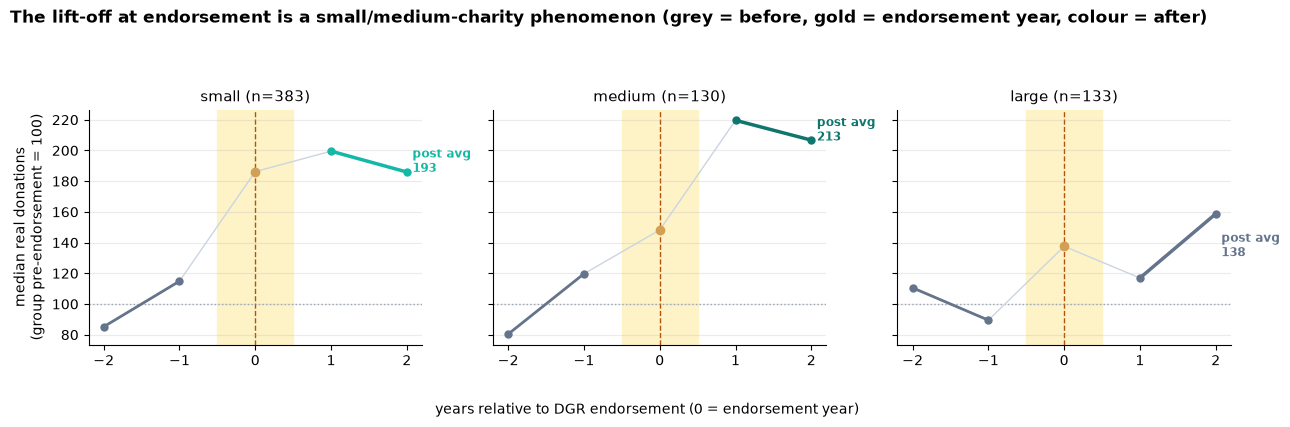

event_year,-2,-1,0,1,2
size,,,,,
large,8972.0,7262.0,11165.0,9493.0,12885.0
medium,5299.0,7892.0,9774.0,14485.0,13633.0
small,5754.0,7759.0,12582.0,13481.0,12563.0


In [13]:
# Chart 2's indexed-trajectory view, grouped by ACNC size (event time, pre = 100)
# Stops at +2: only the earliest cohorts reach +3, so that point is composition-shifted
ev_d = est.copy()
ev_d["size"] = ev_d["abn"].map(size_map)
EV = [-2, -1, 0, 1, 2]

traj = (ev_d[ev_d["event_year"].isin(EV) & ev_d["size"].notna()]
        .groupby(["size", "event_year"], observed=True)["donations_real"]
        .agg(median="median", n="count")
        .reset_index())

size_colors = {"small": "#14b8a6", "medium": "#0f766e", "large": "#64748b"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

for ax, sz in zip(axes, SIZE_ORDER):
    tb = traj[traj["size"] == sz].set_index("event_year")
    base = tb.loc[[y for y in EV if y < 0], "median"].mean()
    idx = 100 * tb["median"] / base
    n_ch = ev_d.loc[ev_d["size"] == sz, "abn"].nunique()

    pre_y = [y for y in idx.index if y < 0]
    post_y = [y for y in idx.index if y >= 1]
    ax.axhline(100, color="#94a3b8", lw=1, ls=":", zorder=1)
    ax.axvspan(-0.5, 0.5, color="#fef3c7", zorder=0)
    ax.axvline(0, color="#b45309", lw=1, ls="--", zorder=1)
    ax.plot(idx.index, idx.values, color="#cbd5e1", lw=1, zorder=2)
    ax.plot(pre_y, idx.loc[pre_y], "o-", color="#64748b", lw=2, ms=5, zorder=3)
    ax.plot(0, idx.loc[0], "o", color="#d1a054", ms=6, zorder=3)
    ax.plot(post_y, idx.loc[post_y], "o-", color=size_colors[sz], lw=2.5, ms=5, zorder=3)

    post_avg = idx.loc[post_y].mean()
    ax.annotate(f"post avg\n{post_avg:.0f}", xy=(max(idx.index), post_avg),
                xytext=(4, 0), textcoords="offset points",
                fontsize=8.5, color=size_colors[sz], fontweight="bold", va="center")

    ax.set_title(f"{sz} (n={n_ch})", fontsize=10.5)
    ax.set_xticks(EV)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("median real donations\n(group pre-endorsement = 100)")
fig.supxlabel("years relative to DGR endorsement (0 = endorsement year)", fontsize=10)
fig.suptitle("The lift-off at endorsement is a small/medium-charity phenomenon "
             "(grey = before, gold = endorsement year, colour = after)",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0.02, 1, 0.9])
plt.show()

# the table behind the chart
traj.pivot(index="size", columns="event_year", values="median").round(0)

## 4. The estimate is robust to "anticipation"

Charities may apply for DGR with donors or a campaign already lined up, so donations start rising *before* endorsement. Two checks on this:

- **No pre-trend**: among charities observed at both event years −2 and −1, the median within-charity change is ~0% and only about half rose — no systematic ramp-up.
- **Clean baseline**: recomputing growth with the baseline restricted to years ≤ −2 (so any ramp-up in year −1 cannot contaminate it) moves the estimate by ~0.3 points.

Charities observed at both -2 and -1: 386
Median within-charity drift -2 to -1: +0.0% (45% rose) -> no pre-endorsement ramp-up


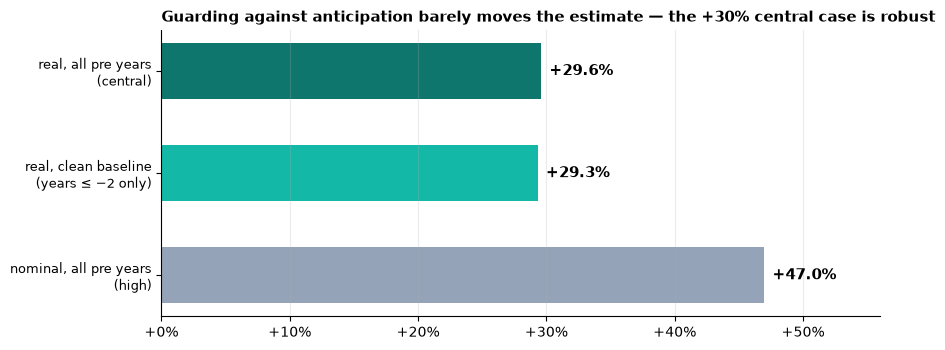

In [5]:
# Pre-trend check + the three estimates side by side
w = (est[est["event_year"].isin([-2, -1])]
     .pivot_table(index="abn", columns="event_year", values="donations_real")
     .dropna())
drift = (w[-1] - w[-2]) / w[-2].clip(lower=1)
print(f"Charities observed at both -2 and -1: {len(w):,}")
print(f"Median within-charity drift -2 to -1: {drift.median():+.1%} "
      f"({(w[-1] > w[-2]).mean():.0%} rose) -> no pre-endorsement ramp-up")

bars = pd.DataFrame({
    "label": ["real, all pre years\n(central)", "real, clean baseline\n(years \u2264 \u22122 only)",
              "nominal, all pre years\n(high)"],
    "value": [real["growth"].median(), clean["growth"].median(), nom["growth"].median()],
    "color": ["#0f766e", "#14b8a6", "#94a3b8"],
})
yp = np.arange(len(bars))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(yp, bars["value"], color=bars["color"], height=0.55)
for i, v in enumerate(bars["value"]):
    ax.annotate(f"+{v:.1%}", (v, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=11, fontweight="bold")
ax.set_yticks(yp); ax.set_yticklabels(bars["label"], fontsize=9.5)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax.set_xlim(0, 0.56)
ax.set_title("Guarding against anticipation barely moves the estimate \u2014 the +30% central case is robust",
             fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Results land inside the Productivity Commission's own predicted range

Everything in this debate is a position on one dial: the **price elasticity of giving** ($\varepsilon$). Deductibility cuts a donor's price of a \\$1 gift to \\$0.68 (at the ~32% marginal rate), so the predicted uplift from gaining DGR is $(1/0.68)^{|\varepsilon|} - 1$.

- **PC Finding 4.1** (ALife panel of 1.5m taxpayers): $\varepsilon$ between −0.48 and −1.67 → predicted uplift **+20% to +90%**. Our +30% sits inside it.
- The **"\\$1 → \\$1.50"** advocacy claim needs $\varepsilon \approx -1.5$; the $\varepsilon = -1$ benchmark predicts +47%.
- The PC measured the dial from the **donor side** and said the charity-side strategy was "not feasible, given insufficient data" (Technical Paper, p. 421). This approach is an attempt to bridge that gap.

**Caveat for any presentation:** our uplift bundles individual deductibility *and* newly unlocked foundation/ancillary money — the AIS reports one donations line. So don't add pool-access dollars on top of the +30%: that double-counts.

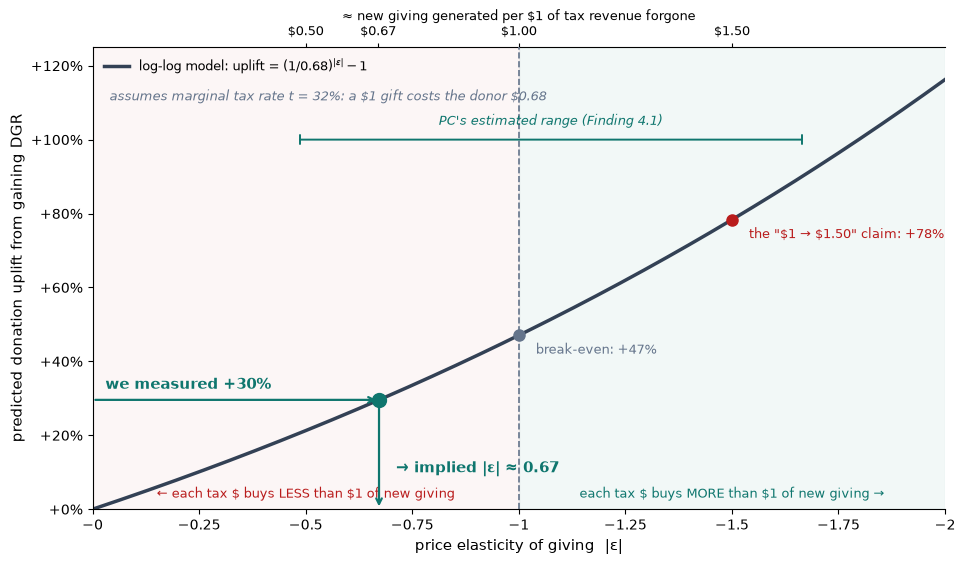

In [4]:
# The dial chart: elasticity -> predicted uplift, with the treasury reading on the top axis
t = 0.32
price = 1 - t
eps = np.linspace(0, 2.0, 400)
uplift = (1 / price) ** eps - 1

med_real_g = real["growth"].median()
eps_real = np.log(1 + med_real_g) / np.log(1 / price)
pc_lo, pc_hi = 0.48, 1.67
u_be = (1 / price) ** 1.0 - 1
u_15 = (1 / price) ** 1.5 - 1

TEAL, GREY, RED, INK = "#0f766e", "#64748b", "#b91c1c", "#334155"

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.25)

# two halves of the argument, split at break-even
ax.axvspan(0, 1.0, color=RED, alpha=0.035, zorder=0)
ax.axvspan(1.0, 2.0, color=TEAL, alpha=0.05, zorder=0)
ax.axvline(1.0, color=GREY, lw=1.2, ls="--", zorder=1)
ax.text(0.5, 0.025, "\u2190 each tax \\$ buys LESS than \\$1 of new giving",
        ha="center", fontsize=9, color=RED, transform=ax.get_xaxis_transform())
ax.text(1.5, 0.025, "each tax \\$ buys MORE than \\$1 of new giving \u2192",
        ha="center", fontsize=9, color=TEAL, transform=ax.get_xaxis_transform())

ax.plot(eps, uplift, color=INK, lw=2.5, zorder=2,
        label="log-log model: uplift = $(1/0.68)^{|\\varepsilon|}-1$")

# PC's estimated range as a bracket, not a background wash
ax.annotate("", xy=(pc_hi, 1.00), xytext=(pc_lo, 1.00),
            arrowprops=dict(arrowstyle="|-|,widthA=0.3,widthB=0.3", color=TEAL, lw=1.4))
ax.text((pc_lo + pc_hi) / 2, 1.04, "PC's estimated range (Finding 4.1)",
        ha="center", fontsize=9, color=TEAL, style="italic")

# inference path: we measured the uplift, then read the curve backwards
ax.annotate("", xy=(eps_real, med_real_g), xytext=(0, med_real_g),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.6))
ax.annotate("", xy=(eps_real, 0), xytext=(eps_real, med_real_g),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.6))
ax.plot(eps_real, med_real_g, "o", color=TEAL, ms=10, zorder=4)
ax.text(0.03, med_real_g + 0.03, f"we measured +{med_real_g:.0%}",
        fontsize=10.5, fontweight="bold", color=TEAL)
ax.text(eps_real + 0.04, 0.10, f"\u2192 implied |\u03b5| \u2248 {eps_real:.2f}",
        fontsize=10.5, fontweight="bold", color=TEAL)

# benchmarks: plain dots, short labels
ax.plot(1.0, u_be, "o", color=GREY, ms=8, zorder=3)
ax.text(1.04, u_be - 0.02, f"break-even: +{u_be:.0%}", fontsize=9.5, color=GREY, va="top")
ax.plot(1.5, u_15, "o", color=RED, ms=8, zorder=3)
ax.text(1.54, u_15 - 0.02, f"the \"\\$1 \u2192 \\$1.50\" claim: +{u_15:.0%}",
        fontsize=9.5, color=RED, va="top")

# the $1 -> $1.50 reading, built into the axis: new giving per tax-$ ~= |eps| at the margin
secax = ax.secondary_xaxis("top")
secax.set_xticks([0.5, round(eps_real, 2), 1.0, 1.5])
secax.set_xticklabels(["$0.50", f"${eps_real:.2f}", "$1.00", "$1.50"], fontsize=9)
secax.set_xlabel("\u2248 new giving generated per $1 of tax revenue forgone", fontsize=9.5)
secax.tick_params(length=3)

ax.set_xlabel("price elasticity of giving  |\u03b5|", fontsize=11)
ax.set_ylabel("predicted donation uplift from gaining DGR", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"\u2212{v:g}"))
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.02, 0.885, f"assumes marginal tax rate t = {t:.0%}: a \\$1 gift costs the donor \\${price:.2f}",
        transform=ax.transAxes, fontsize=9, color=GREY, style="italic")
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## Summary

| # | Message | Evidence |
|---|---|---|
| 1 | Typical newly endorsed charity: **+30% real** donation growth (+47% nominal) | Growth ladder — the median of 646 charities |
| 2 | The timing tracks each cohort's own endorsement year | Staggered cohort panels |
| 3 | Growth concentrated in small-base charities — the reform-gainer profile | Size-band split |
| 4 | No pre-trend; anticipation-robust estimate ~29% | Drift test + clean baseline |
| 5 | Implied elasticity ≈ −0.67, inside PC's −0.48 to −1.67 | Elasticity dial |

**Use in the reform modelling:** the central +30% is applied to the donation bases of newly eligible charities in `reform_scenario_impact.R`. Do **not** stack pool-access dollars on top (double-counting, see §5).

In [7]:
summary = pd.DataFrame({
    "estimate": ["central (real)", "high (nominal)", "robustness: clean baseline (real)"],
    "definition": [
        "real $, pre = all years < 0, post = years >= 1",
        "nominal $, same pre/post",
        "real $, pre restricted to years <= -2",
    ],
    "median_uplift": [real["growth"].median(), nom["growth"].median(), clean["growth"].median()],
    "n_charities": [len(real), len(nom), len(clean)],
})
summary["median_uplift"] = (100 * summary["median_uplift"]).round(1).astype(str) + "%"
summary

,estimate,definition,median_uplift,n_charities
0,central (real),"real $, pre = all years < 0, post = years >= 1",29.6%,646
1,high (nominal),"nominal $, same pre/post",47.0%,646
2,robustness: clean baseline (real),"real $, pre restricted to years <= -2",29.3%,400
